In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine
from urllib.parse import quote_plus # Para manejar las contraseñas con caracteres especiales
%matplotlib inline

In [3]:
# 1. Credenciales de la Base de Datos LOCAL
DB_USER = "postgres"
DB_PASS = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "myvolt_local"

# 2. Codificar la contraseña
DB_PASS_ENCODED = quote_plus(DB_PASS)

# 3. Crear la cadena de conexión
try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(connection_string)
    
    # 4. Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a PostgreSQL LOCAL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a la BD Local: {e}")
    print("Consejo: Verifica que tu contraseña sea correcta y que PostgreSQL esté corriendo en el puerto 5432.")

¡Conexión a PostgreSQL LOCAL exitosa!


In [4]:
# Opción: Traer datos de consumo
# IMPORTANTE: Asegúrate de que estos datos correspondan al comportamiento del REFRIGERADOR
query = """
SELECT time, power_w
FROM consumption_data
ORDER BY time DESC; 
"""

df = pd.read_sql_query(query, con=engine)
print(f"Se cargaron {len(df)} registros para el Refrigerador.")
df.head()

Se cargaron 28179 registros para el Refrigerador.


,time,power_w
0,2025-11-24 22:41:15.468 -0600,34.01
1,2025-11-24 22:41:14.558 -0600,34.01
2,2025-11-24 22:41:13.445 -0600,27.21
3,2025-11-24 22:41:12.447 -0600,34.01
4,2025-11-24 22:41:11.592 -0600,34.01


In [5]:
datos_para_modelo = df[['power_w']]
datos_para_modelo.head()

,power_w
0,34.01
1,34.01
2,27.21
3,34.01
4,34.01


In [6]:
# Contamination 0.1 asume que el 10% de los datos podrían ser ruido o anomalías
modelo_if = IsolationForest(contamination=0.1, random_state=42)
modelo_if.fit(datos_para_modelo)
print("¡Modelo del REFRIGERADOR entrenado exitosamente!")

¡Modelo del REFRIGERADOR entrenado exitosamente!


In [7]:
predicciones = modelo_if.predict(datos_para_modelo)
df['anomalia_predicha'] = predicciones
anomalias = df[df['anomalia_predicha'] == -1]
print(f"El modelo detectó {len(anomalias)} anomalías de un total de {len(df)} registros.")
print("\nEjemplos de potencias anómalas (W) encontradas:")
print(anomalias['power_w'].value_counts().head())

El modelo detectó 889 anomalías de un total de 28179 registros.

Ejemplos de potencias anómalas (W) encontradas:
power_w
6.80     620
28.57     62
29.93     49
13.61     35
1.36      28
Name: count, dtype: int64


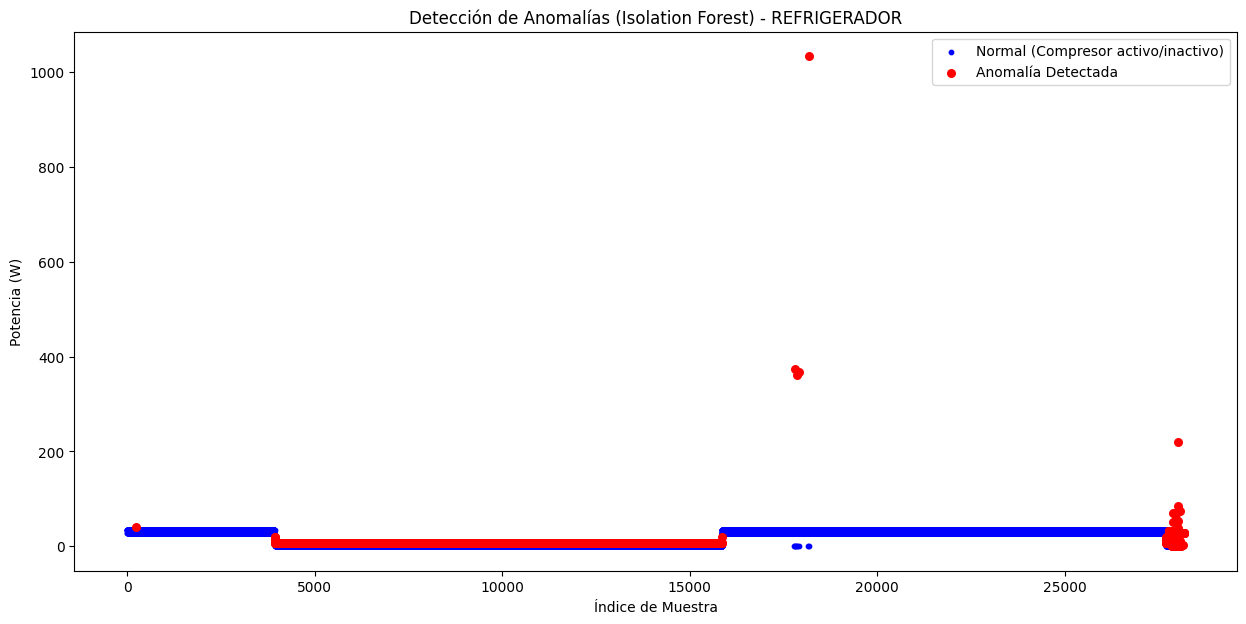

In [8]:
df_normal = df[df['anomalia_predicha'] == 1]
df_anomalo = df[df['anomalia_predicha'] == -1]

plt.figure(figsize=(15, 7))

# Pintamos los puntos normales en azul
# Para el Refri, deberías ver ciclos normales entre 150W y 600W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Compresor activo/inactivo)', s=10)

# Pintamos las anomalías en rojo (Picos muy altos o valores extraños fuera de rango)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía Detectada', s=30)

plt.title('Detección de Anomalías (Isolation Forest) - REFRIGERADOR')

plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [ ]:
# Guardamos con nombre específico para el Main Universal
ruta_modelo = '../models/models_v2/modelo_refrigerador.pkl' 

joblib.dump(modelo_if, ruta_modelo)

print(f"¡ML del Refrigerador guardado exitosamente en {ruta_modelo}!")

¡Modelo del REFRIGERADOR guardado exitosamente en ../models/models_v1/refrigerador_isolation_forest_v1.pkl!
